In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"D:\sales_data.csv")
df.head()

,Region,Salesperson,Revenue,Profit,Units_Sold,Customer_Satisfaction,Marketing_Spend,Discount_Percentage,Product_Category,Sales_Channel,Order_Processing_Time
0,East,Alice,137118,10067,219,4.06,14666,13.40,Furniture,Retail,1
1,West,Alice,78577,38481,750,2.64,8254,3.70,Automobile,Wholesale,3
2,North,Alice,19078,28037,406,3.62,14746,6.18,Furniture,Retail,3
3,East,Eve,166075,10557,109,2.04,4578,0.03,Furniture,Online,5
4,East,David,72768,10435,40,1.64,13353,1.18,Electronics,Wholesale,3


In [4]:
# Check dataset information
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (1000, 11)

Column names:
['Region', 'Salesperson', 'Revenue', 'Profit', 'Units_Sold', 'Customer_Satisfaction', 'Marketing_Spend', 'Discount_Percentage', 'Product_Category', 'Sales_Channel', 'Order_Processing_Time']

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Region                 1000 non-null   str    
 1   Salesperson            1000 non-null   str    
 2   Revenue                1000 non-null   int64  
 3   Profit                 1000 non-null   int64  
 4   Units_Sold             1000 non-null   int64  
 5   Customer_Satisfaction  1000 non-null   float64
 6   Marketing_Spend        1000 non-null   int64  
 7   Discount_Percentage    1000 non-null   float64
 8   Product_Category       1000 non-null   str    
 9   Sales_Channel          1000 non-null   str    
 10  Order_Processing_Tim

In [5]:
# Remove duplicate rows
df = df.drop_duplicates()

# Check duplicates
print("Duplicate rows:", df.duplicated().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

Duplicate rows: 0

Data types:
Region                       str
Salesperson                  str
Revenue                    int64
Profit                     int64
Units_Sold                 int64
Customer_Satisfaction    float64
Marketing_Spend            int64
Discount_Percentage      float64
Product_Category             str
Sales_Channel                str
Order_Processing_Time      int64
dtype: object


In [7]:
# Basic sales analysis

print("Total Revenue:", df["Revenue"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Units Sold:", df["Units_Sold"].sum())
print("\nAverage Customer Satisfaction:",
      df["Customer_Satisfaction"].mean())
print("\nAverage Order Processing Time:",
      df["Order_Processing_Time"].mean())

Total Revenue: 107315608
Total Profit: 23973118
Total Units Sold: 498594

Average Customer Satisfaction: 2.96342

Average Order Processing Time: 4.963


In [8]:
# Region-wise sales analysis

region_analysis = df.groupby("Region")[["Revenue", "Profit", "Units_Sold"]].sum()

region_analysis

,Revenue,Profit,Units_Sold
Region,,,
East,25438195,5352301,121886
North,29373063,6027453,129266
South,23876202,5509219,114225
West,28628148,7084145,133217


In [9]:
# Sort regions by Revenue

region_analysis.sort_values("Revenue", ascending=False)

,Revenue,Profit,Units_Sold
Region,,,
North,29373063,6027453,129266
West,28628148,7084145,133217
East,25438195,5352301,121886
South,23876202,5509219,114225


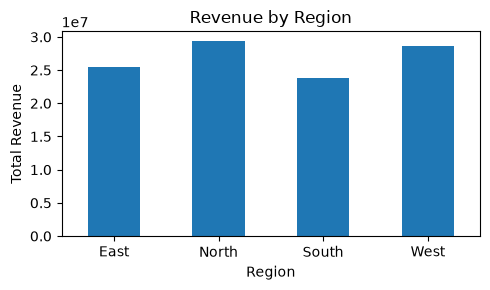

In [23]:
# Region-wise Revenue

region_revenue = df.groupby("Region")["Revenue"].sum()

region_revenue.plot(kind="bar", figsize=(5, 3))

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:

# Product Category-wise analysis

category_analysis = df.groupby("Product_Category")[[
    "Revenue",
    "Profit",
    "Units_Sold"
]].sum()

category_analysis

,Revenue,Profit,Units_Sold
Product_Category,,,
Automobile,19922097,4799427,94655
Clothing,22711315,4837222,109159
Electronics,23172817,4623100,103196
Furniture,20612653,4951074,94381
Grocery,20896726,4762295,97203


In [12]:
# Categories ranked by Revenue

category_analysis.sort_values(
    "Revenue",
    ascending=False
)

,Revenue,Profit,Units_Sold
Product_Category,,,
Electronics,23172817,4623100,103196
Clothing,22711315,4837222,109159
Grocery,20896726,4762295,97203
Furniture,20612653,4951074,94381
Automobile,19922097,4799427,94655


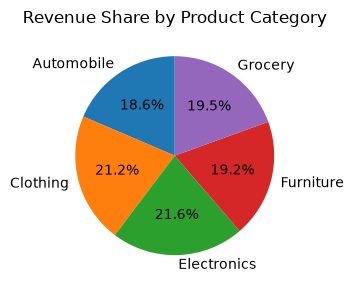

In [22]:
# Revenue Share by Product Category

category_revenue = df.groupby("Product_Category")["Revenue"].sum()

plt.figure(figsize=(5, 3))

plt.pie(
    category_revenue,
    labels=category_revenue.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Revenue Share by Product Category")
plt.tight_layout()
plt.show()

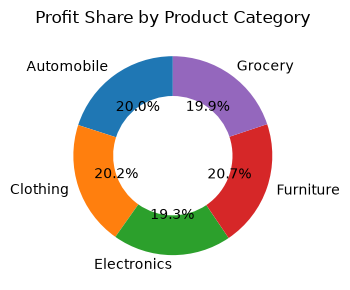

In [21]:
# Profit Share by Product Category

category_profit = df.groupby("Product_Category")["Profit"].sum()

plt.figure(figsize=(5, 3))

plt.pie(
    category_profit,
    labels=category_profit.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Profit Share by Product Category")
plt.tight_layout()
plt.show()

In [15]:
# Salesperson performance analysis

salesperson_analysis = df.groupby("Salesperson")[[
    "Revenue",
    "Profit",
    "Units_Sold"
]].sum()

salesperson_analysis

,Revenue,Profit,Units_Sold
Salesperson,,,
Alice,22945316,5222232,106448
Bob,22209168,4473236,102373
Charlie,21599594,4946703,102771
David,18071268,4298661,87449
Eve,22490262,5032286,99553


In [16]:
# Top salespersons by Revenue

top_salespersons = salesperson_analysis.sort_values(
    "Revenue",
    ascending=False
)

top_salespersons

,Revenue,Profit,Units_Sold
Salesperson,,,
Alice,22945316,5222232,106448
Eve,22490262,5032286,99553
Bob,22209168,4473236,102373
Charlie,21599594,4946703,102771
David,18071268,4298661,87449


In [17]:
# Top 5 Salespersons by Revenue

top_5_salespersons = top_salespersons.head(5)

top_5_salespersons

,Revenue,Profit,Units_Sold
Salesperson,,,
Alice,22945316,5222232,106448
Eve,22490262,5032286,99553
Bob,22209168,4473236,102373
Charlie,21599594,4946703,102771
David,18071268,4298661,87449


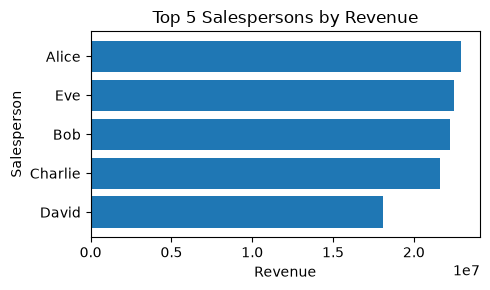

In [20]:
# Top 5 Salespersons by Revenue

top_5_revenue = top_5_salespersons["Revenue"].sort_values()

plt.figure(figsize=(5, 3))

plt.barh(
    top_5_revenue.index,
    top_5_revenue.values
)

plt.title("Top 5 Salespersons by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Salesperson")

plt.tight_layout()
plt.show()